https://docs.google.com/presentation/d/1gFsafUbz-_6oZ-CkffzpL8hAU6tSRbtt/edit#slide=id.p9

# # Q1.Make a function to calculate the moment(Torque) applied to the lever

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as num
get_ipython().run_line_magic('matplotlib', 'inline')


In [2]:
APPLIED_FORCE = 10 #N
LEVER_LENGTH = 6 #m

In [3]:
def calculate_moment( FORCE,LENGTH):
    moment = (APPLIED_FORCE*LEVER_LENGTH)
    
    return moment

In [4]:
mom = calculate_moment(APPLIED_FORCE,LEVER_LENGTH);


print(f"The moment is {mom} Nm")

The moment is 60 Nm


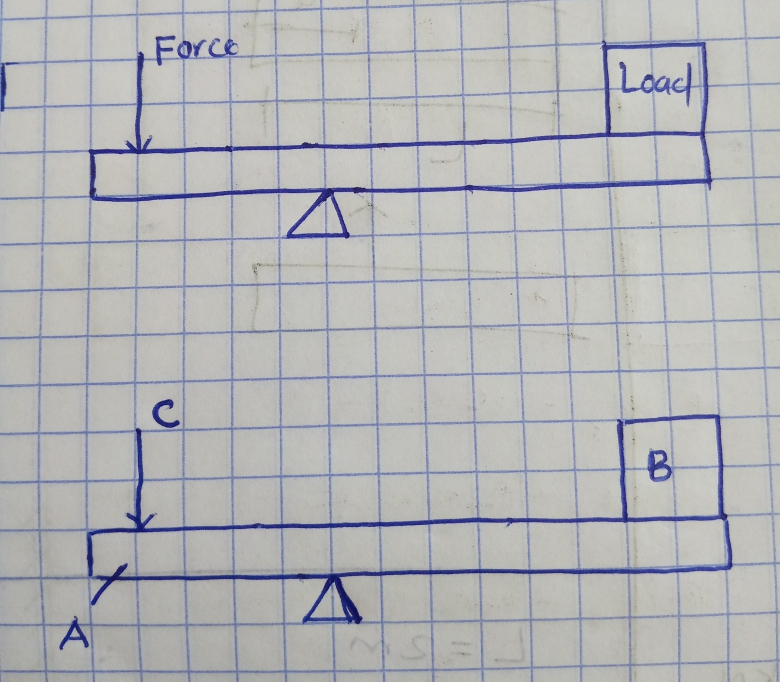

# # Q2.calculate the tension in a cable  holding a load at an angle


In [5]:
LOAD_WEIGHT = 15 #N
ANGLE_DEGREES = 45 #degrees
ANGLE_RADIANS = np.radians(ANGLE_DEGREES)

In [6]:
def calculate_tension(LOAD_WEIGHT,ANGLE_DEGREES):
    tension = np.round(LOAD_WEIGHT/np.cos(ANGLE_RADIANS),4)
    
    return tension

In [7]:

ten = calculate_tension(LOAD_WEIGHT,ANGLE_DEGREES);


print(f"The tension is {ten} N")

The tension is 21.2132 N


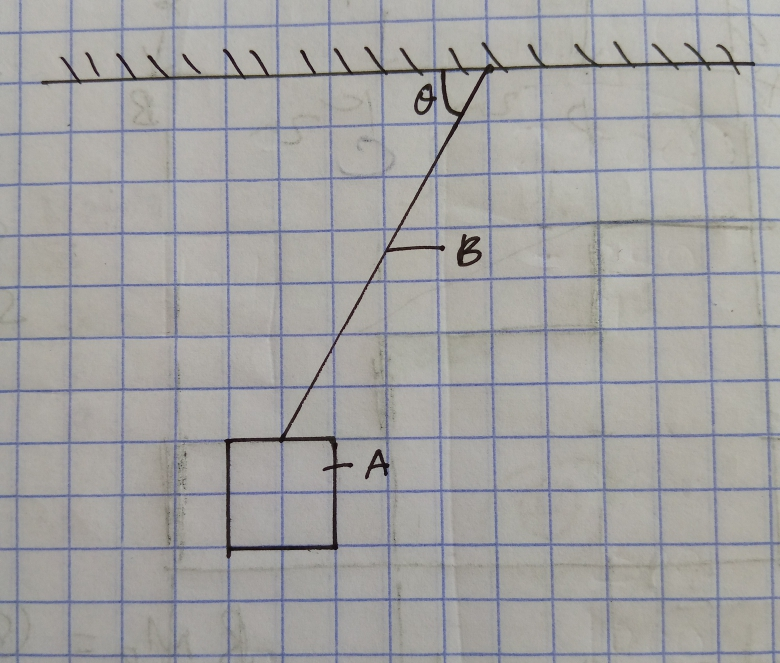


# # Q3.calculate the stress on a beam subject to a bending moment

In [8]:
BENDING_MOMENT = 10.4 #N.m
DISTANCE = 0.45 #m
SECOND_MOMENT_OF_INERTIA = 43.6   #(m^4)

In [9]:
def calculate_stress(BENDING_MOMENT,DISTANCE,SECOND_MOMENT_OF_INERTIA):
    stress = np.round((BENDING_MOMENT*DISTANCE)/SECOND_MOMENT_OF_INERTIA,4)
    
    return stress

In [10]:
st = calculate_stress(BENDING_MOMENT,DISTANCE,SECOND_MOMENT_OF_INERTIA);


print(f"The stress is {st} N/m^2")

The stress is 0.1073 N/m^2


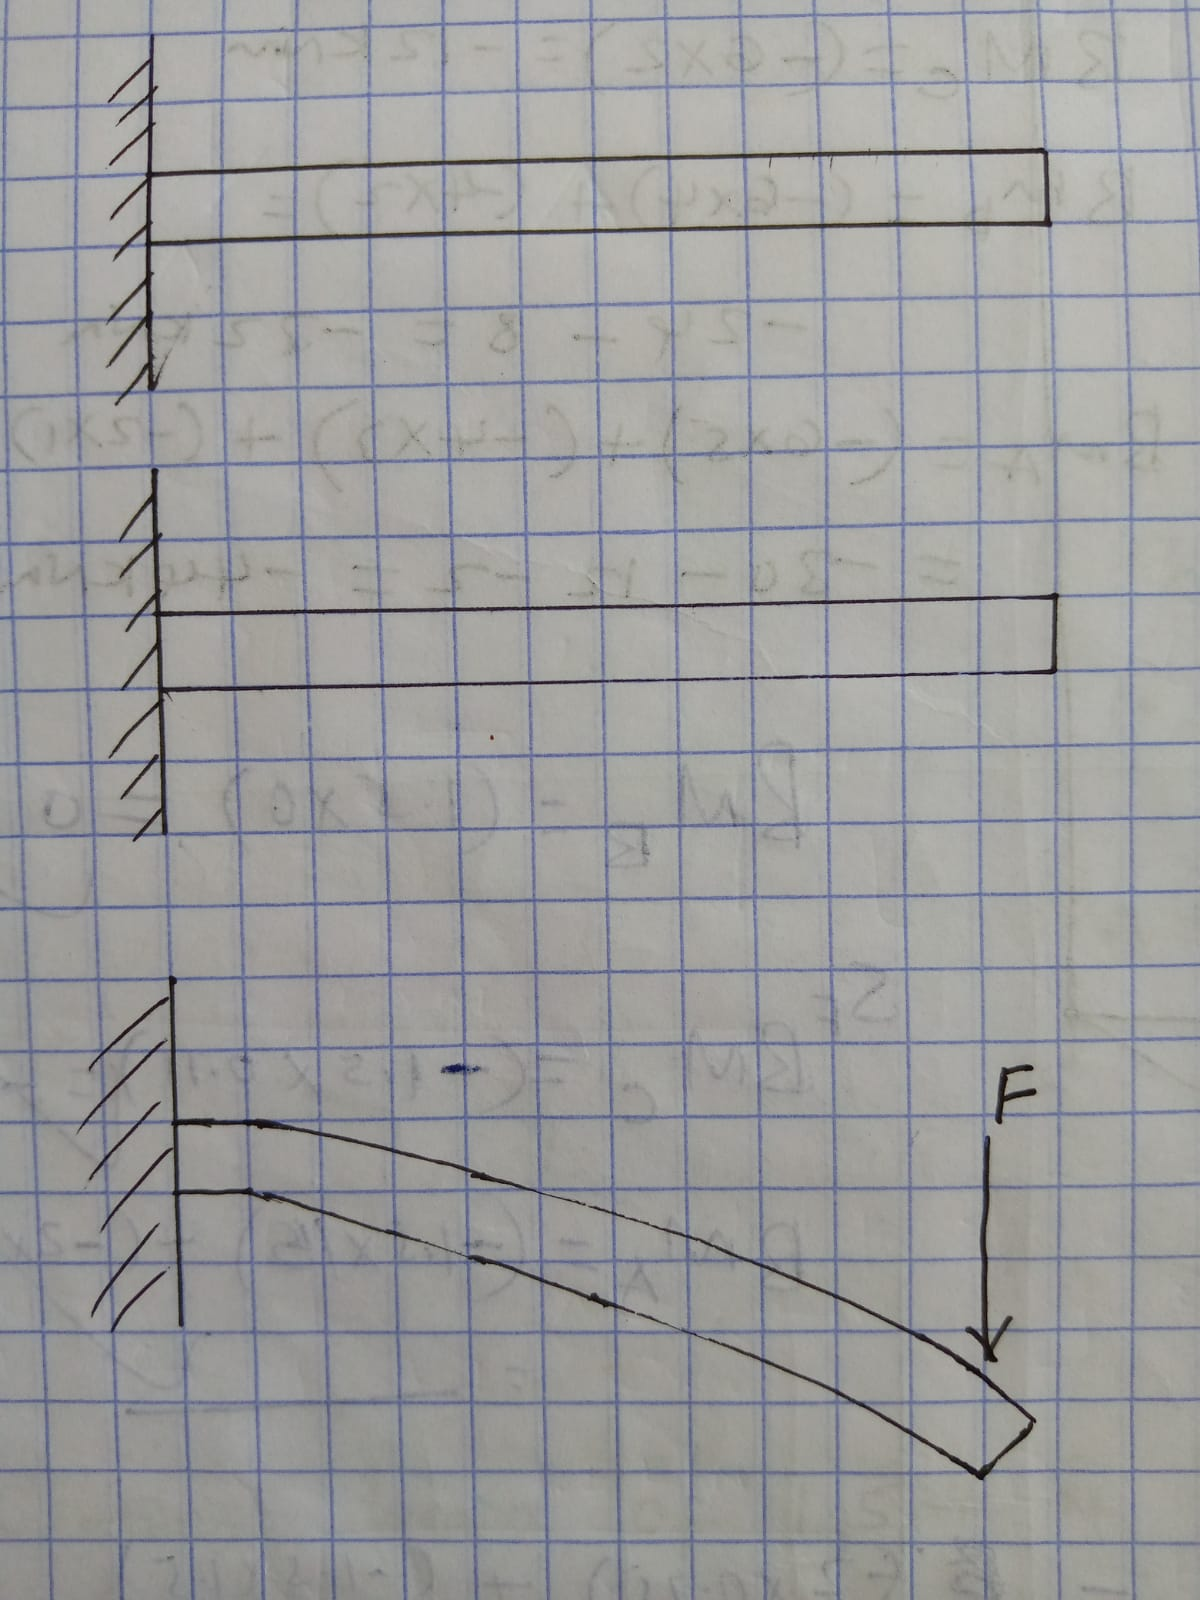

# # Q4. calculate the shear forces and bending moments for a cantilever beam of length 1.5m carrying point load

In [11]:
force_A = 0
force_B = -1.5 #kN
force_C = -2 #kN

Distance_A = 0 #m
Distance_B = 1.5 #m
Distance_C = 0.5 #m

In [12]:
def calculate_shear_force_A(force_B,force_C):
    shear_forceA =(force_B + force_C)
    
    return shear_forceA

def calculate_shear_force_C(force_B,force_C):
    shear_forceC =(force_B + force_C)
    
    return shear_forceC

In [13]:
def calculate_bending_moment_A(force_B,Distance_B,force_C,Distance_C):
    bending_momentA =((-force_B * Distance_B) + (-force_C * Distance_C) )
    
    return bending_momentA

def calculate_bending_moment_C(force_B,Distance_C):
    bending_momentC =(-force_B * Distance_C )

In [14]:
shear = calculate_shear_force_A(force_B,force_C);

print(f"The shear force acting at point A is {shear} kN")


shear = calculate_shear_force_C(force_B,force_C);

print(f"The shear force acting at point C is {shear} kN")

momentA = calculate_bending_moment_A(force_B,Distance_B,force_C,Distance_C);

print(f"The bending moment acting at point A is {momentA} Nm")


momentC = calculate_bending_moment_C(force_B,Distance_C);

print(f"The bending moment acting at point c is {momentC} Nm")


The shear force acting at point A is -3.5 kN
The shear force acting at point C is -3.5 kN
The bending moment acting at point A is 3.25 Nm
The bending moment acting at point c is None Nm


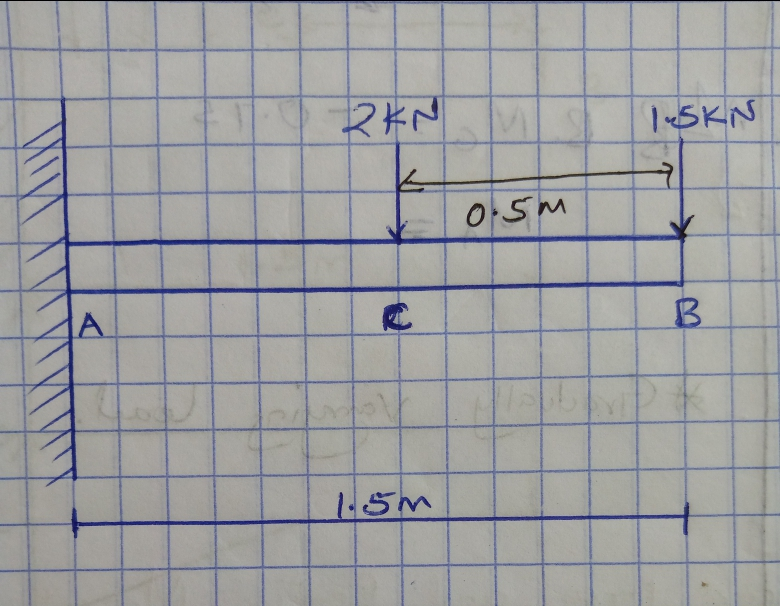

# # Q5.Make a function to calculate shear forces and bending moments on a cantilever beam AB , which is 2m long, carrying a uniformly distributed load of 1.5kN/m over a length of 1.6m from the free end

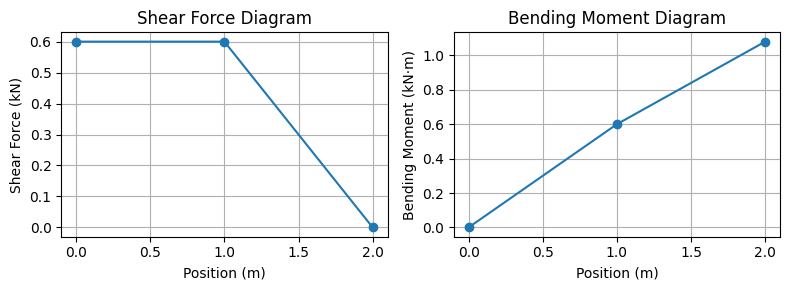

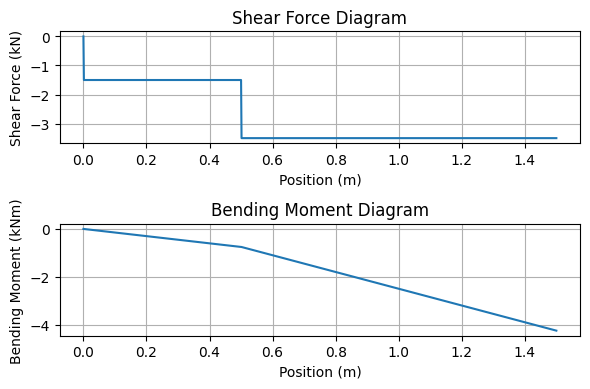

In [15]:
def plot_cantilever_beam_shear_bending(length, load_position, load_intensity):
    # Calculate shear and bending moment values
    def calculate_shear_bending(length, load_position, load_intensity):
        reactions = load_intensity * (length - load_position)
        shear_values = []
        bending_moment_values = []

        # Section 1: From the fixed end to the start of the load
        for x in range(int(load_position) + 1):
            shear = reactions
            moment = reactions * x
            shear_values.append(shear)
            bending_moment_values.append(moment)

        # Section 2: From the start of the load to the free end
        for x in range(int(load_position) + 1, int(length) + 1):
            shear = reactions - load_intensity * (x - load_position)
            moment = reactions * x - load_intensity * (x - load_position)**2 / 2
            shear_values.append(shear)
            bending_moment_values.append(moment)

        return shear_values, bending_moment_values

    shear_values, bending_moment_values = calculate_shear_bending(length, load_position, load_intensity)

    # Create the position values
    positions = [x for x in range(int(length) + 1)]

    # Plot shear force
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.plot(positions, shear_values, marker='o')
    plt.title("Shear Force Diagram")
    plt.xlabel("Position (m)")
    plt.ylabel("Shear Force (kN)")
    plt.grid(True)

    # Plot bending moment
    plt.subplot(1, 2, 2)
    plt.plot(positions, bending_moment_values, marker='o')
    plt.title("Bending Moment Diagram")
    plt.xlabel("Position (m)")
    plt.ylabel("Bending Moment (kN·m)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Input values
beam_length = 2.0  # meters
load_position = 1.6  # meters
load_intensity = 1.5  # kN/m

# Call the function to plot the diagrams
plot_cantilever_beam_shear_bending(beam_length, load_position, load_intensity)


# Define beam properties
beam_length = 1.5  # Length of the beam in meters
loads = [(2.0, 0.5), (1.5, 0)]  # List of (load, position) tuples in kN and meters

# Create an array of x values along the beam
x = np.linspace(0, beam_length, 1000)

# Initialize empty arrays for shear force and bending moment
shear_force = np.zeros_like(x)
bending_moment = np.zeros_like(x)

# Calculate shear force and bending moment at each x position
for i in range(len(x)):
    for load, position in loads:
        if x[i] > position:
            shear_force[i] += -load  # Negative because the loads are applied downward
            bending_moment[i] += -load * (x[i] - position)
    
# Create the plots
plt.figure(figsize=(6, 4))

# Shear Force Diagram
plt.subplot(2, 1, 1)
plt.plot(x, shear_force)
plt.title("Shear Force Diagram")
plt.xlabel("Position (m)")
plt.ylabel("Shear Force (kN)")
plt.grid(True)

# Bending Moment Diagram
plt.subplot(2, 1, 2)
plt.plot(x, bending_moment)
plt.title("Bending Moment Diagram")
plt.xlabel("Position (m)")
plt.ylabel("Bending Moment (kNm)")
plt.grid(True)

plt.tight_layout()
plt.show()



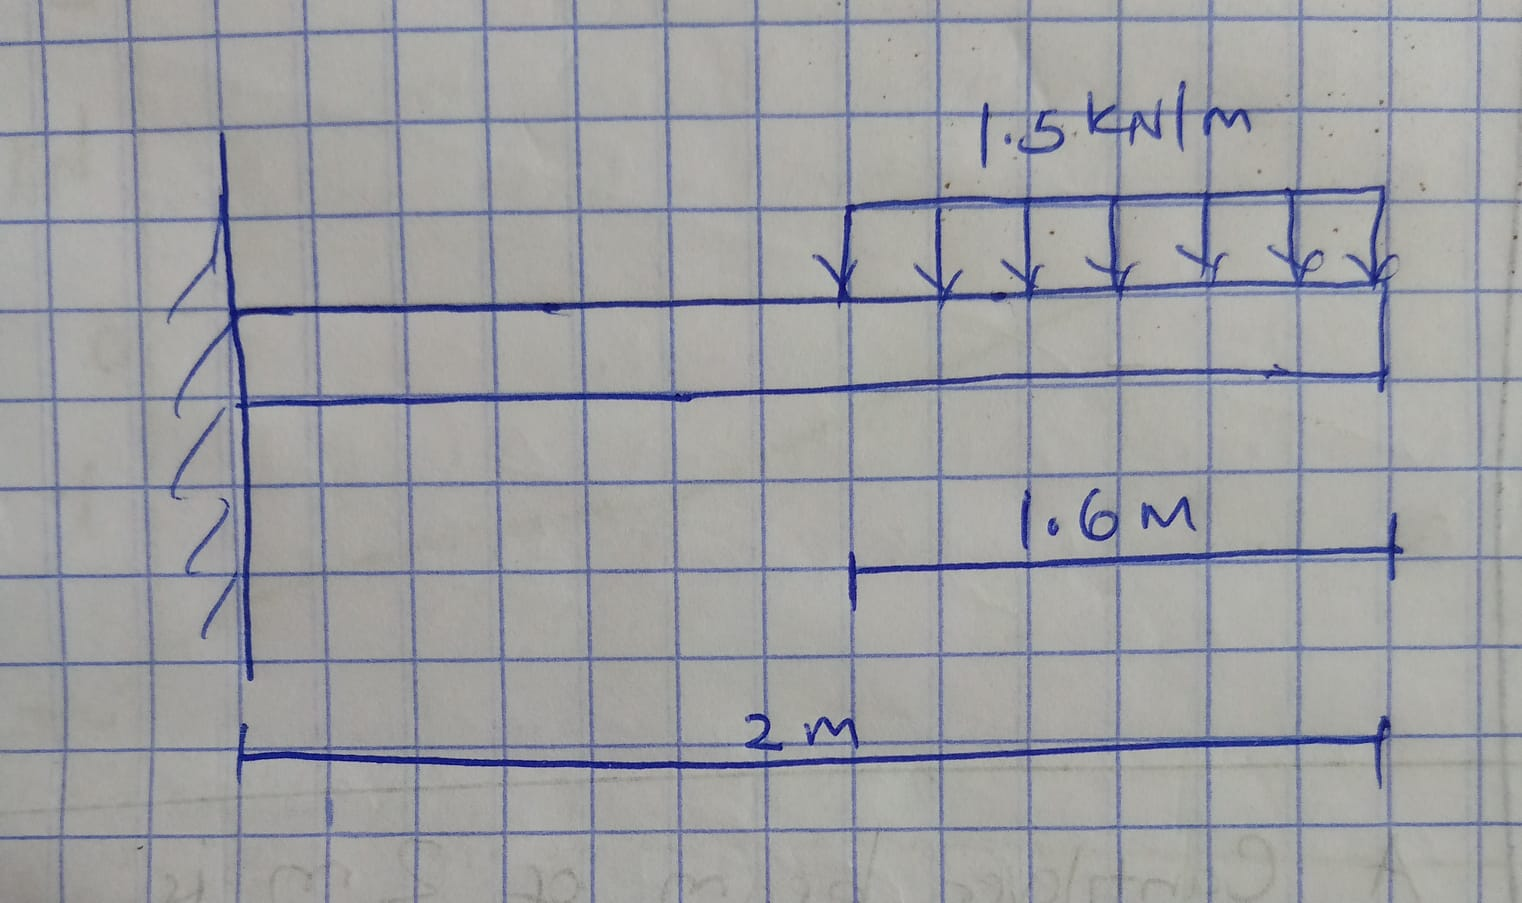

# # Q6. A cantilever beam of 1.5m is loaded as shown below. Draw a shear force and bending moment diagrams

In [16]:
length = 1.5  # m
uniform_load_length = 1.0 # m
uniform_load = 1 #kN/m
point_load = 2.0  # kN
point_load_length = 0.5 # m

def cantilever_beam(length, uniform_load, uniform_load_length, point_load, point_load_length):
    
    # Calculate shear force and bending moment at point A
    V_A = point_load + uniform_load
    M_A = -(point_load * length +  uniform_load * uniform_load_length/2)

    # Calculate shear force and bending moment at point C (0.5 m from the free end)
    V_C = point_load
    M_C = -(point_load * point_load_length)

    # Calculate shear force and bending moment at point B (free end)
    V_B = point_load
    M_B = point_load * 0

    return {
        'Point A': {'Shear Force': V_A, 'Bending Moment': M_A},
        'Point C': {'Shear Force': V_C, 'Bending Moment': M_C},
        'Point B': {'Shear Force': V_B, 'Bending Moment': M_B}
    }

results = cantilever_beam (length, uniform_load, uniform_load_length, point_load, point_load_length)

# Display the results
for point, values in results.items():
    print(f"{point}:")
    print(f"Shear Force: {values['Shear Force']} kN")
    print(f"Bending Moment: {values['Bending Moment']} kNm")
    print()

# Create a list of positions along the beam
positions = [0,0,1.0,length]

# Create a list of shear force values at these positions
shear_forces = [results['Point A']['Shear Force'],
                results['Point A']['Shear Force'],
                results['Point C']['Shear Force'],
                results['Point B']['Shear Force']]
Bending_moment = [results['Point A']['Bending Moment'],
                results['Point A']['Bending Moment'],
                results['Point C']['Bending Moment'],
                results['Point B']['Bending Moment']]


Point A:
Shear Force: 3.0 kN
Bending Moment: -3.5 kNm

Point C:
Shear Force: 2.0 kN
Bending Moment: -1.0 kNm

Point B:
Shear Force: 2.0 kN
Bending Moment: 0.0 kNm



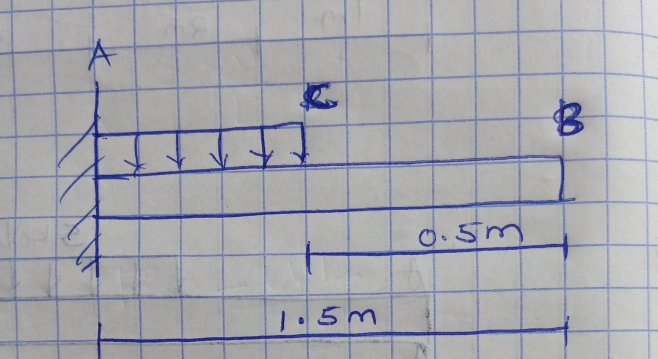

# Q7. A cantilever beam of 2m is subjectec to a gradually varying load from 2kN/m to 5kN/m. Plot the shear force and the bending moment diagram

Point A:
Shear Force: 7.0 kN
Bending Moment: -6.0 kNm

Point B:
Shear Force: 0 kN
Bending Moment: 0 kNm



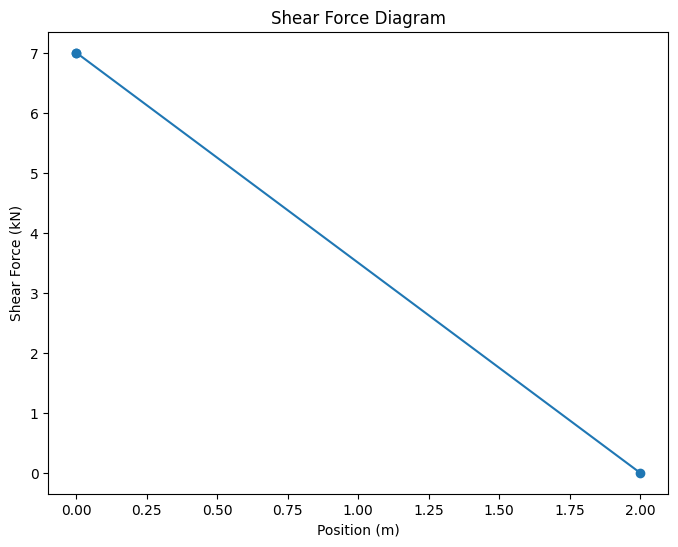

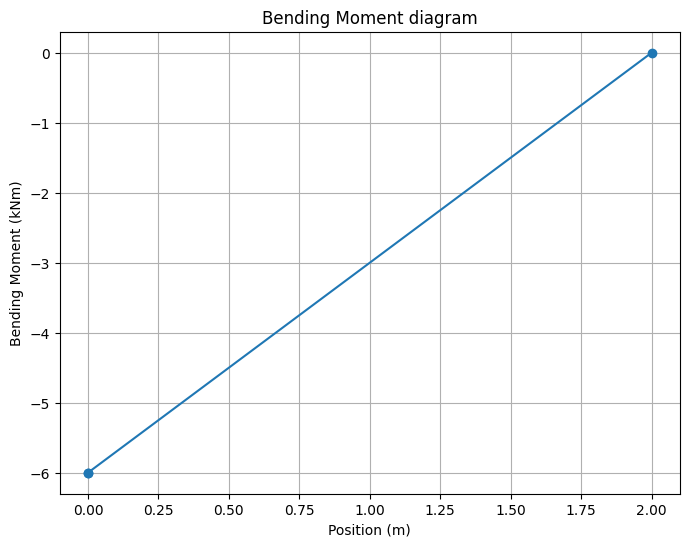

In [17]:
def cantilever_beam_analysis (length, uniform_load, gradually_varying_load):
    
    # Calculate shear force and bending moment at point A
    F_A = (uniform_load * length) + (1/2 * length * gradually_varying_load)
    M_A = -(2 * 2**2 / 2 + 1/2 * 2 *3 *2/3)

   
    # Calculate shear force and bending moment at point B (free end)
    F_B = 0
    M_B = 0

    return {
        'Point A': {'Shear Force': F_A, 'Bending Moment': M_A},
        'Point B': {'Shear Force': F_B, 'Bending Moment': M_B}
    }

length = 2
gradually_varying_load = 3
uniform_load = 2
    

results = cantilever_beam_analysis(length,uniform_load, gradually_varying_load)

# Display the results
for point, values in results.items():
    print(f"{point}:")
    print(f"Shear Force: {values['Shear Force']} kN")
    print(f"Bending Moment: {values['Bending Moment']} kNm")
    print()
    
    # Create a list of positions along the beam
positions = [0,0,length]

# Create a list of shear force values at these positions
shear_forces = [results['Point A']['Shear Force'],
                results['Point A']['Shear Force'],
                results['Point B']['Shear Force']]
Bending_moment = [results['Point A']['Bending Moment'],
                results['Point A']['Bending Moment'],
                results['Point B']['Bending Moment']]

# Plot the shear force diagram
plt.figure(figsize=(8, 6))
plt.plot(positions, shear_forces, marker='o', linestyle='-')
plt.title('Shear Force Diagram')
plt.xlabel('Position (m)')
plt.ylabel('Shear Force (kN)')


plt.figure(figsize=(8, 6))
plt.plot(positions, Bending_moment, marker='o', linestyle='-')
plt.title('Bending Moment diagram')
plt.xlabel('Position (m)')
plt.ylabel('Bending Moment (kNm)')

plt.grid(True)
plt.show()

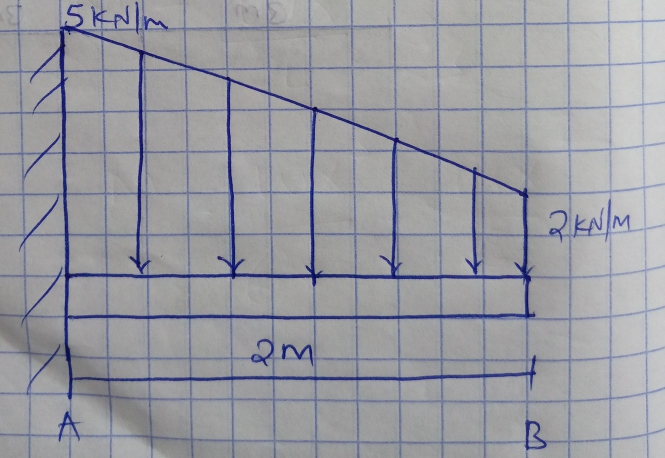

# Q8. A simply supported beam of 5m long is loaded with a uniform;y distributed load of 10kN/m over a length of 2m.

In [18]:
def calculate_shear_force_and_bending_moment(length, load, distance_from_A):
    # Define support reactions
    reaction_A = load * (length - distance_from_A) / length
    reaction_B = load * distance_from_A / length

    # Calculate shear force and bending moment at the specified point
    if distance_from_A < 0 or distance_from_A > length:
        return None, None  # Point is outside the beam

    # Shear force calculation
    shear_force = reaction_A
    if distance_from_A > 0:
        shear_force -= load * distance_from_A / length

    # Bending moment calculation
    bending_moment = reaction_A * distance_from_A
    if distance_from_A > 0:
        bending_moment -= load * distance_from_A * distance_from_A / (2 * length)

    return shear_force, bending_moment

# Input values
beam_length = 5  # meters
uniform_load = 10  # kN/m
load_position = 1  # meters from point A

# Calculate shear force and bending moment at the specified point
shear_force, bending_moment = calculate_shear_force_and_bending_moment(beam_length, uniform_load, load_position)

if shear_force is not None and bending_moment is not None:
    print(f"At a point {load_position} m from point A:")
    print(f"Shear Force: {shear_force} kN")
    print(f"Bending Moment: {bending_moment} kNm")
else:
    print("The specified point is outside the beam.")

At a point 1 m from point A:
Shear Force: 6.0 kN
Bending Moment: 7.0 kNm


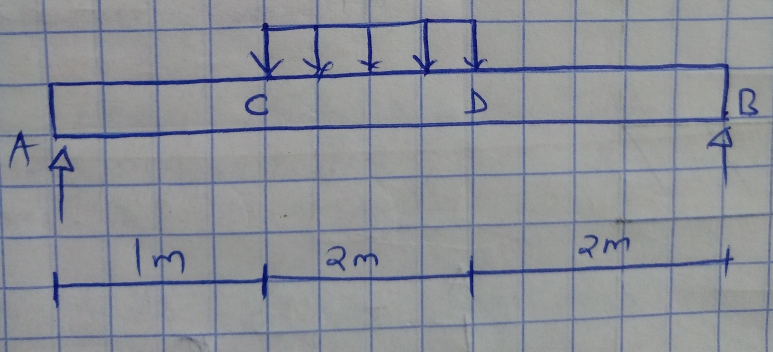

# Q9. A simply supported beam of 6m long is loaded with a uniform;y distributed load of 5kN/m over a length of 3m.

Point A:
Shear Force: 3.75 kN
Bending Moment: 0 kNm

Point C:
Shear Force: 3.75 kN
Bending Moment: 11.25 kNm

Point B:
Shear Force: -11.25 kN
Bending Moment: 0 kNm



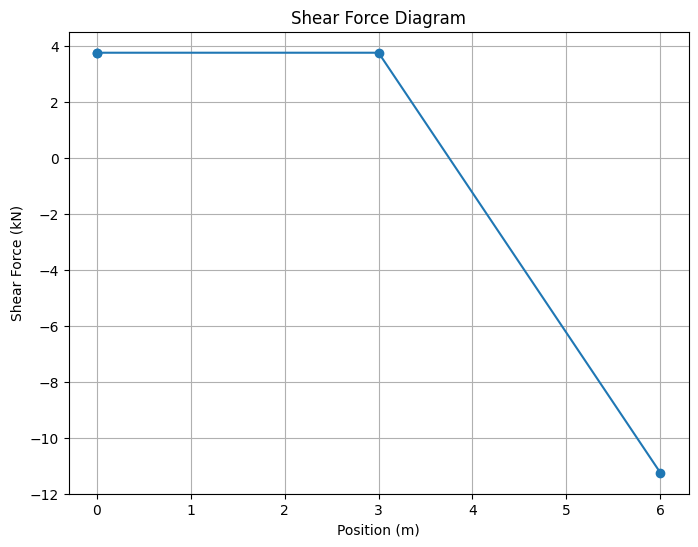

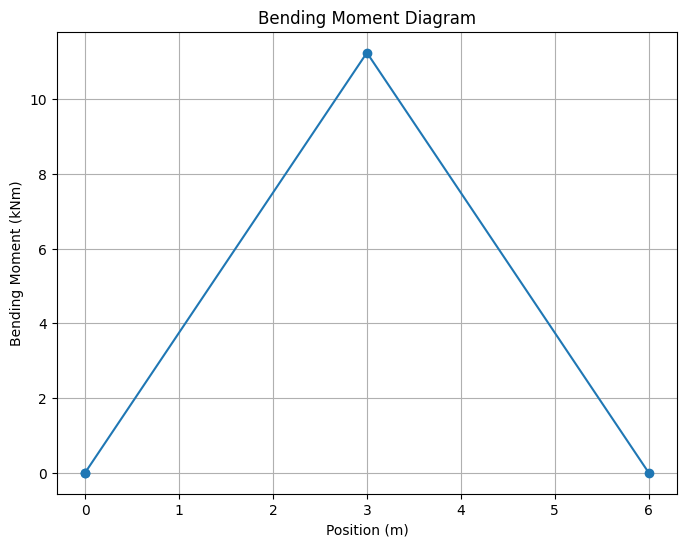

In [19]:
def cantilever_beam(length, W_1):
    # Assuming R_B is the reaction force at B
    R_B = (W_1 * 3) * 4.5/length
    R_A = (W_1 * 3) - R_B
    
    # Calculate shear force and bending moment at point A
    F_A = +R_A
    M_A = 0

    # Calculate shear force and bending moment at point C
    F_C = R_A
    M_C = R_A * 3 

    # Calculate shear force and bending moment at point B (free end)
    F_B = R_A - (W_1*3)
    M_B = 0
    
    return {
        'Point A': {'Shear Force': F_A, 'Bending Moment': M_A},
        'Point C': {'Shear Force': F_C, 'Bending Moment': M_C},
        'Point B': {'Shear Force': F_B, 'Bending Moment': M_B}
    }

length = 6
W_1 = 5

results = cantilever_beam(length, W_1)

# Display the results
for point, values in results.items():
    print(f"{point}:")
    print(f"Shear Force: {values['Shear Force']} kN")
    print(f"Bending Moment: {values['Bending Moment']} kNm")
    print()

# Create a list of positions along the beam
positions = [0, 0, 3.0, length]

# Create a list of shear force values at these positions
shear_forces = [results['Point A']['Shear Force'],
                results['Point A']['Shear Force'],
                results['Point C']['Shear Force'],
                results['Point B']['Shear Force']]
bending_moments = [results['Point A']['Bending Moment'],
                   results['Point A']['Bending Moment'],
                   results['Point C']['Bending Moment'],
                   results['Point B']['Bending Moment']]

# Plot the shear force diagram
plt.figure(figsize=(8, 6))
plt.plot(positions, shear_forces, marker='o', linestyle='-')
plt.title('Shear Force Diagram')
plt.xlabel('Position (m)')
plt.ylabel('Shear Force (kN)')
plt.grid(True)
plt.show()

# Plot the bending moment diagram
plt.figure(figsize=(8, 6))
plt.plot(positions, bending_moments, marker='o', linestyle='-')
plt.title('Bending Moment Diagram')
plt.xlabel('Position (m)')
plt.ylabel('Bending Moment (kNm)')
plt.grid(True)
plt.show()

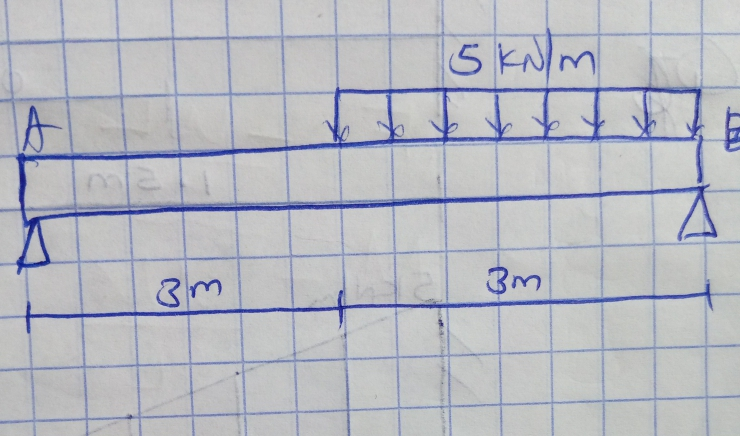

# Q10. In Figure , two wooden planks b2 = h1 = 150 mm and  b1 = h2 = 50 mm each areconnected to form a T section of a beam. If a moment of 6.4kN-m is applied around the horizontal neutral axis, inducing tension below the neutral axis, find the bending stresses at both the extreme fibres of the cross-section. The goal is to utilize a Python function for versatile and scalable design solutions for diverse client needs. Determine the moment of inertia for the section using a Python function. The Python program function should calculate bending stress in the upper andlower extreme fibres of the section.

In [20]:
b1=50
h1=150
b2=150
h2=50
moment=6.4
def Moment_of_Inertia():
    #moment of inertia of the lower rectangle
    Inertia_1=(1/12*b1*h1**3)
    #moment of inertia of the upper rectangle
    Inertia_2=(1/12*b2*h2**3)
    #area of the rectangles
    A1= b1*h1
    A2= b2*h2
    Total_area= A1+A2
    #calculate centroids
    y1=h1/2
    y2=h2/2+h1
    Centroid=(A1*y1+A2*y2)/Total_area
    
    d1= Centroid-y1
    d2=Centroid-y2
    #area of moment of inertia
    Inertia=(Inertia_1+A1*d1**2)+(Inertia_2+A2*d2**2)
    Upper_stress = ((moment/Inertia)*Centroid)
    Lower_stress = ((moment/Inertia)*y1)
    
    print(f"Moment of Inertia: {Inertia}mm^4")
    print(f"Bending stress in the upper part: {Upper_stress}N/mm^2")
    print(f"Bending stress in the lower part: {Lower_stress}N/mm^2")
    
Moment_of_Inertia()

Moment of Inertia: 53125000.0mm^4
Bending stress in the upper part: 1.5058823529411764e-05N/mm^2
Bending stress in the lower part: 9.035294117647059e-06N/mm^2


![Q10.jpg](attachment:Q10.jpg)

# 11. Question Ten
### Figure  shows a rolled steel beam of an unsymmetrical I-section. If the maximum  bending stress in the beam section is not to exceed 40MPa, find the moment that the beam can resist. b1 = h2 = 200 mm, b3 = 100 mm, h1 = h3 = 50 mm. Determine the moment of inertia for the section using a Python function.The Python program function should calculate the moment that the beam can resist without exceeding the maximum bending stress. 

In [21]:
b1=200 #mm
h1=50 #mm
b2=50 #mm
h2=200 #mm
b3=100 #mm
h3=50 #mm
bending_stress= 40 #MPa
total_height= h1+h2+h3
def Moment_of_Inertia():
    #calculate moment of inertia for each rectangle
    I_1 = (1/12*b1*h1**3)
    I_2 = (1/12*b2*h2**3)
    I_3 = (1/12*b3*h3**3)
    #calculate area of each reactangle
    A1 = b1*h1
    A2 = b2*h2
    A3 = b3*h3
    total_area = A1 + A2 + A3
    #Centroid of each rectangle
    y1 = h1/2 
    y2 = h2/2+h1
    y3 = h3/2+h2+h1
    Centroid = ((A1*y1) + (A2*y2) + (A3*y3))/ (total_area)
    y = total_height - Centroid
    d1 = Centroid - y1
    d2 = Centroid - y2
    d3 = Centroid - y3
    
    Moment_of_Inertia = (I_1 +A1*d1**2)+(I_2 +A2*d2**2)+(I_3 +A3*d3**2)
    
    Modulus_of_the_section = (Moment_of_Inertia/y)
    
    Moment_beam_can_resist = (bending_stress*Modulus_of_the_section)
    
    print(f"Centroid of the Section is: {Centroid}mm")
    print(f"Moment of Inertia is: {Moment_of_Inertia}mm^4")
    print(f"Modulus of the section is: {Modulus_of_the_section}mm^3")
    print(f"Moment which the beam can resist is: {Moment_beam_can_resist} Nm")
    
Moment_of_Inertia() 

Centroid of the Section is: 125.0mm
Moment of Inertia is: 255208333.3333333mm^4
Modulus of the section is: 1458333.3333333333mm^3
Moment which the beam can resist is: 58333333.33333333 Nm


![Q11.jpg](attachment:Q11.jpg)